In [ ]:
# MOUNT, IMPORTS, INSTALLS

from google.colab import drive
drive.mount('/content/drive')

!pip install -q xgboost shap imbalanced-learn fairlearn statsmodels scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import shapiro, kstest, beta as beta_dist

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor, VotingClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, matthews_corrcoef, RocCurveDisplay,
    mean_squared_error, r2_score, roc_curve, auc
)
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

import xgboost as xgb
import shap
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import SMOTE
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

BASE_PATH = '/content/drive/MyDrive/Datasets'
PLOT_DIR  = '/content/drive/MyDrive/Datasets/Methodology Plots'
os.makedirs(PLOT_DIR, exist_ok=True)

def save_plot(filename):
    path = os.path.join(PLOT_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')

def standardize_fips(df, col):
    df = df.copy()
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=[col])
    df[col] = df[col].astype(int).astype(str).str.zfill(5)
    return df

print('All imports loaded')
print(f'Methodology plots will save to: {PLOT_DIR}')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 18.5 MB/s eta 0:00:00
All imports loaded
Methodology plots will save to: /content/drive/MyDrive/Datasets/Methodology Plots


In [ ]:
# RELOAD ALL DATASETS

print('RELOADING ALL DATASETS')

mlr_years = []
mlr_base  = os.path.join(BASE_PATH, 'MLR Denial Data')
for subfolder in sorted(os.listdir(mlr_base)):
    if subfolder.startswith('.'): continue
    sub_path = os.path.join(mlr_base, subfolder)
    if not os.path.isdir(sub_path): continue
    for f in os.listdir(sub_path):
        if 'Part3' in f and f.endswith('.csv') and 'Notes' not in f:
            df = pd.read_csv(os.path.join(sub_path, f), low_memory=False)
            df['_year'] = subfolder.replace('MLR_','').replace('MLR-','').replace('mlr-','')
            mlr_years.append(df)
mlr_part3 = pd.concat(mlr_years, ignore_index=True)

ind_cy  = next((c for c in mlr_part3.columns if 'CMM_INDIVIDUAL_CY' == c.upper()), None)
ind_tot = next((c for c in mlr_part3.columns if 'CMM_INDIVIDUAL_TOTAL' == c.upper()), None)
if ind_cy and ind_tot:
    mlr_part3['MLR_RATIO'] = (
        pd.to_numeric(mlr_part3[ind_cy], errors='coerce') /
        pd.to_numeric(mlr_part3[ind_tot], errors='coerce')
    )
print(f'MLR Part3: {mlr_part3.shape}')

# Landscape - cache as CSV for faster reloads
land_csv = os.path.join(BASE_PATH, 'Landscape', 'landscape_2023_cached.csv')
if os.path.exists(land_csv):
    land = pd.read_csv(land_csv, low_memory=False)
    print(f'Landscape (from cache): {land.shape}')
else:
    land = pd.read_excel(
        os.path.join(BASE_PATH, 'Landscape', 'Individual_Market_Medical-2023.xlsx'),
        header=1, usecols=['State Code','FIPS County Code','County Name',
                           'Issuer Name','Metal Level','Plan Type'])
    land = land.dropna(subset=['FIPS County Code'])
    land['FIPS'] = land['FIPS County Code'].astype(str).str.zfill(5)
    land = land.rename(columns={'State Code': 'STATE'}).drop(columns=['FIPS County Code'])
    land.to_csv(land_csv, index=False)
    print(f'Landscape (converted and cached): {land.shape}')

svi = pd.read_csv(os.path.join(BASE_PATH, 'CDC SVI', 'SVI_2022_US_county.csv'))
svi = standardize_fips(svi, 'FIPS')
print(f'SVI: {svi.shape}')

places = pd.read_csv(os.path.join(BASE_PATH, 'CDC Places',
         'PLACES__County_Data__GIS_Friendly_Format___2025_release.csv'))
places = standardize_fips(places, 'CountyFIPS')
print(f'PLACES: {places.shape}')

hrsa = pd.read_csv(os.path.join(BASE_PATH, 'HRSA', 'AHRF 2023-2024 CSV',
       'CSV Files by Categories', 'ahrf2024geo_Feb2025.csv'), low_memory=False)
hrsa = standardize_fips(hrsa, 'fips_st_cnty')
hrsa = hrsa.rename(columns={'fips_st_cnty': 'FIPS'})
print(f'HRSA: {hrsa.shape}')

county = svi.copy()
county = county.merge(places.rename(columns={'CountyFIPS':'FIPS'}),
                      on='FIPS', how='left', suffixes=('','_places'))
county = county.merge(hrsa[['FIPS','rural_urban_contnm_23']],
                      on='FIPS', how='left')
print(f'County master: {county.shape}')

synpuf_path = os.path.join(BASE_PATH, 'Individual Claim denails')

bene = pd.read_csv(os.path.join(synpuf_path,
       'DE1_0_2008_Beneficiary_Summary_File_Sample_1.csv'))
race_map = {1:'White', 2:'Black', 3:'Other', 5:'Hispanic'}
sex_map  = {1:'Male',  2:'Female'}
bene['RACE_LABEL'] = bene['BENE_RACE_CD'].map(race_map).fillna('Unknown')
bene['SEX_LABEL']  = bene['BENE_SEX_IDENT_CD'].map(sex_map).fillna('Unknown')
bene['AGE'] = 2008 - (bene['BENE_BIRTH_DT'] // 10000)

claims = pd.read_csv(os.path.join(synpuf_path,
         'DE1_0_2008_to_2010_Inpatient_Claims_Sample_1.csv'))
claims['CLM_PMT_AMT'] = pd.to_numeric(claims['CLM_PMT_AMT'], errors='coerce')
claims['DENIED'] = (claims['CLM_PMT_AMT'] == 0).astype(int)

merged = claims.merge(
    bene[['DESYNPUF_ID','RACE_LABEL','SEX_LABEL','AGE',
          'SP_DIABETES','SP_CHF','SP_COPD','SP_CNCR',
          'SP_DEPRESSN','SP_ALZHDMTA','SP_ISCHMCHT']],
    on='DESYNPUF_ID', how='left'
)
print(f'Merged claims+bene: {merged.shape}')
print(f'Denial rate: {merged["DENIED"].mean()*100:.2f}%')
print('All datasets loaded')

RELOADING ALL DATASETS
MLR Part3: (649125, 84)
Landscape (converted and cached): (134912, 6)
SVI: (3144, 158)
PLACES: (3143, 167)
HRSA: (3240, 57)
County master: (3144, 325)
Merged claims+bene: (66773, 92)
Denial rate: 3.23%
All datasets loaded


Valid MLR records: 45,500
Mean: 0.5449
Median: 0.3807
Std: 0.3465
Skewness: 0.4574
Kurtosis: -1.1742

Shapiro-Wilk test (n=5000):
  W = 0.8493, p = 2.30e-56
  Reject normality at alpha=0.05

Beta distribution fit (on [0,1] subset, n=32,437):
  alpha = 1.281, beta = 2.142
  KS test: D = 0.1664, p = 0.00e+00


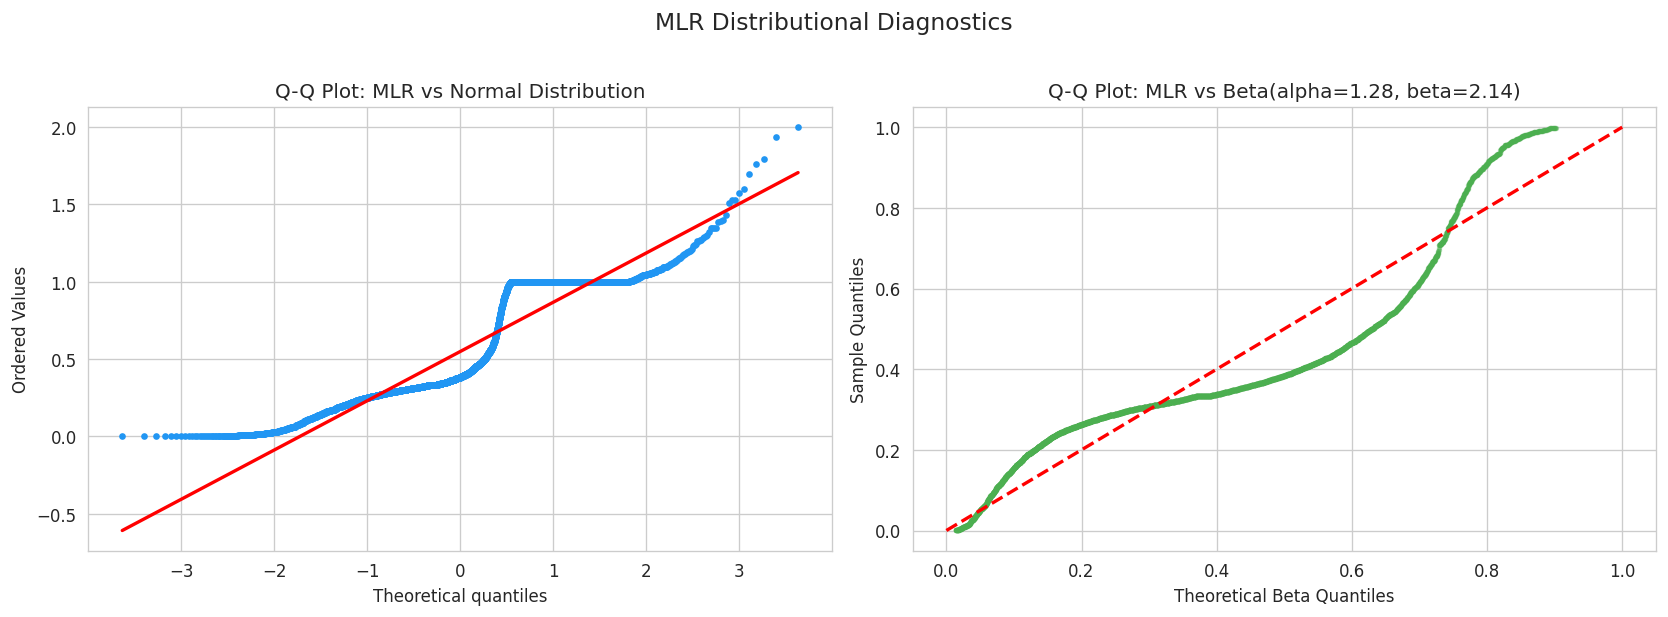

Saved: M01_mlr_qq_plots.png


In [ ]:
# 1.1 MLR DISTRIBUTIONAL DIAGNOSTICS

valid_mlr = mlr_part3['MLR_RATIO'].dropna()
valid_mlr = valid_mlr[valid_mlr.between(0.001, 1.999)]

print(f'Valid MLR records: {len(valid_mlr):,}')
print(f'Mean: {valid_mlr.mean():.4f}')
print(f'Median: {valid_mlr.median():.4f}')
print(f'Std: {valid_mlr.std():.4f}')
print(f'Skewness: {valid_mlr.skew():.4f}')
print(f'Kurtosis: {valid_mlr.kurtosis():.4f}')

sample = valid_mlr.sample(min(5000, len(valid_mlr)), random_state=42)
sw_stat, sw_pval = shapiro(sample)
print(f'\nShapiro-Wilk test (n={len(sample)}):')
print(f'  W = {sw_stat:.4f}, p = {sw_pval:.2e}')
print(f'  {"Reject" if sw_pval < 0.05 else "Fail to reject"} normality at alpha=0.05')

mlr_01 = valid_mlr[valid_mlr.between(0.001, 0.999)]
a_hat, b_hat, loc_hat, scale_hat = beta_dist.fit(mlr_01, floc=0, fscale=1)
print(f'\nBeta distribution fit (on [0,1] subset, n={len(mlr_01):,}):')
print(f'  alpha = {a_hat:.3f}, beta = {b_hat:.3f}')

ks_stat, ks_pval = kstest(mlr_01, 'beta', args=(a_hat, b_hat, loc_hat, scale_hat))
print(f'  KS test: D = {ks_stat:.4f}, p = {ks_pval:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(sample, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot: MLR vs Normal Distribution', fontsize=12)
axes[0].get_lines()[0].set(color='#2196F3', markersize=3)
axes[0].get_lines()[1].set(color='red', linewidth=2)

beta_sample = mlr_01.sample(min(5000, len(mlr_01)), random_state=42)
theoretical_q = beta_dist.ppf(np.linspace(0.01, 0.99, len(beta_sample)),
                               a_hat, b_hat)
empirical_q = np.sort(beta_sample.values)[:len(theoretical_q)]
axes[1].scatter(theoretical_q, empirical_q, s=5, alpha=0.4, color='#4CAF50')
axes[1].plot([0, 1], [0, 1], 'r--', lw=2)
axes[1].set_xlabel('Theoretical Beta Quantiles')
axes[1].set_ylabel('Sample Quantiles')
axes[1].set_title(f'Q-Q Plot: MLR vs Beta(alpha={a_hat:.2f}, beta={b_hat:.2f})', fontsize=12)

plt.suptitle('MLR Distributional Diagnostics', fontsize=14, y=1.02)
save_plot('M01_mlr_qq_plots.png')

SVI variables for VIF: 14
Complete cases: 3,144

Variance Inflation Factors:
  EP_DISABL       VIF =    32.00 **HIGH**
  EP_POV150       VIF =    29.54 **HIGH**
  EP_HBURD        VIF =    28.38 **HIGH**
  EP_AGE17        VIF =    22.18 **HIGH**
  EP_AGE65        VIF =    20.35 **HIGH**
  EP_NOHSDP       VIF =    18.59 **HIGH**
  EP_SNGPNT       VIF =    13.81 **HIGH**
  EP_UNEMP        VIF =     8.41
  EP_UNINSUR      VIF =     7.76
  EP_MINRTY       VIF =     7.16
  EP_MOBILE       VIF =     5.46
  EP_NOVEH        VIF =     4.38
  EP_MUNIT        VIF =     3.45
  EP_LIMENG       VIF =     3.30


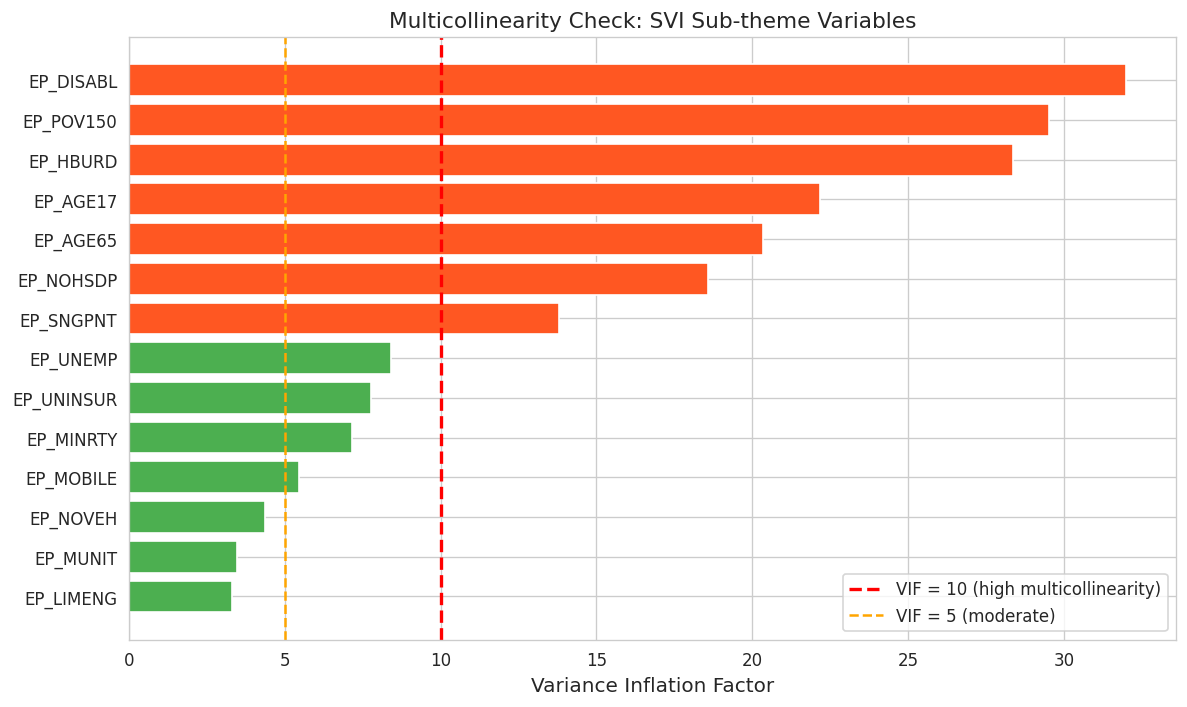

Saved: M02_vif_analysis.png

Running PCA on SVI variables...
PC1: 30.0% variance
PC2: 20.3% variance
PC3: 12.5% variance
First 3 PCs: 62.8% cumulative variance


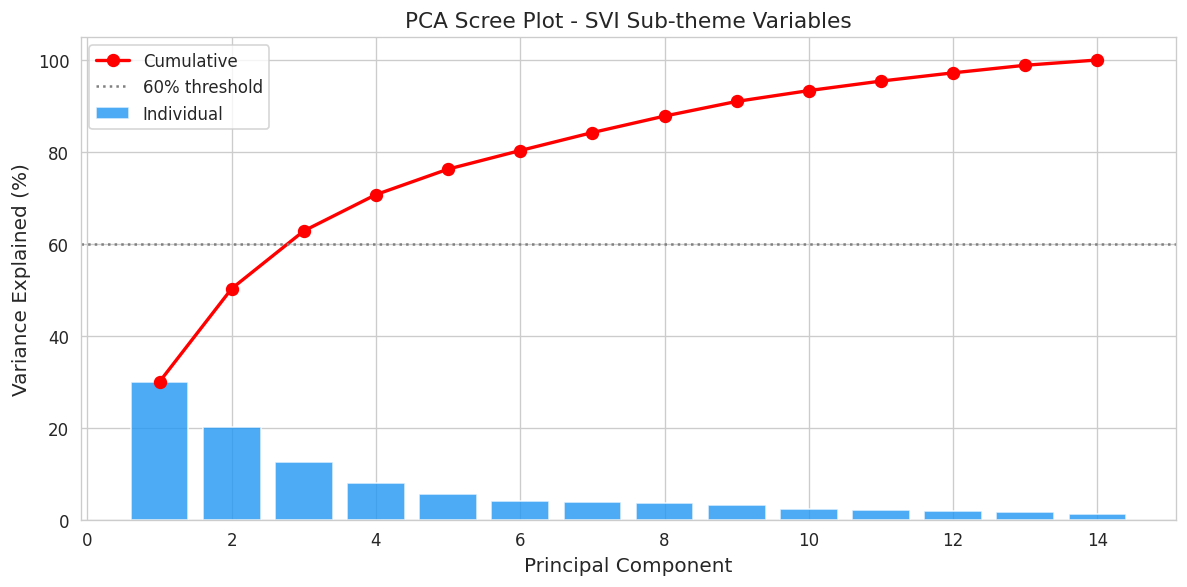

Saved: M03_pca_scree_plot.png


In [ ]:
# 1.2 SVI MULTICOLLINEARITY AND PCA

from statsmodels.stats.outliers_influence import variance_inflation_factor

svi_vars = ['EP_POV150','EP_UNEMP','EP_HBURD','EP_NOHSDP',
            'EP_UNINSUR','EP_AGE65','EP_AGE17','EP_DISABL',
            'EP_SNGPNT','EP_LIMENG','EP_MINRTY','EP_MUNIT',
            'EP_MOBILE','EP_NOVEH']

svi_vars = [c for c in svi_vars if c in svi.columns]
svi_numeric = svi[svi_vars].apply(pd.to_numeric, errors='coerce').dropna()

print(f'SVI variables for VIF: {len(svi_vars)}')
print(f'Complete cases: {len(svi_numeric):,}')

vif_data = pd.DataFrame({
    'Variable': svi_vars,
    'VIF': [variance_inflation_factor(svi_numeric.values, i)
            for i in range(len(svi_vars))]
}).sort_values('VIF', ascending=False)

print('\nVariance Inflation Factors:')
for _, row in vif_data.iterrows():
    flag = ' **HIGH**' if row['VIF'] > 10 else ''
    print(f'  {row["Variable"]:<15} VIF = {row["VIF"]:>8.2f}{flag}')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#FF5722' if v > 10 else '#4CAF50' for v in vif_data['VIF']]
ax.barh(vif_data['Variable'], vif_data['VIF'], color=colors, edgecolor='white')
ax.axvline(10, color='red', linestyle='--', lw=2, label='VIF = 10 (high multicollinearity)')
ax.axvline(5, color='orange', linestyle='--', lw=1.5, label='VIF = 5 (moderate)')
ax.set_xlabel('Variance Inflation Factor', fontsize=12)
ax.set_title('Multicollinearity Check: SVI Sub-theme Variables', fontsize=13)
ax.legend()
ax.invert_yaxis()
save_plot('M02_vif_analysis.png')

print('\nRunning PCA on SVI variables...')
scaler = StandardScaler()
svi_scaled = scaler.fit_transform(svi_numeric)

pca = PCA(n_components=len(svi_vars))
pca.fit(svi_scaled)

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
print(f'PC1: {pca.explained_variance_ratio_[0]*100:.1f}% variance')
print(f'PC2: {pca.explained_variance_ratio_[1]*100:.1f}% variance')
print(f'PC3: {pca.explained_variance_ratio_[2]*100:.1f}% variance')
print(f'First 3 PCs: {cumvar[2]:.1f}% cumulative variance')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(svi_vars)+1), pca.explained_variance_ratio_*100,
       color='#2196F3', edgecolor='white', alpha=0.8, label='Individual')
ax.plot(range(1, len(svi_vars)+1), cumvar,
        'ro-', lw=2, markersize=7, label='Cumulative')
ax.axhline(60, color='gray', linestyle=':', lw=1.5, label='60% threshold')
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Variance Explained (%)', fontsize=12)
ax.set_title('PCA Scree Plot - SVI Sub-theme Variables', fontsize=13)
ax.legend()
save_plot('M03_pca_scree_plot.png')

In [ ]:
# 1.3 FEATURE ENGINEERING - DE-SynPUF

cond_cols = ['SP_DIABETES','SP_CHF','SP_COPD','SP_CNCR',
             'SP_DEPRESSN','SP_ALZHDMTA','SP_ISCHMCHT']
existing = [c for c in cond_cols if c in merged.columns]

merged['CONDITION_COUNT'] = (
    merged[existing].apply(pd.to_numeric, errors='coerce') == 1
).sum(axis=1)

merged['HAS_MULTI_CONDITIONS'] = (merged['CONDITION_COUNT'] >= 3).astype(int)

merged['AGE_GROUP'] = pd.cut(
    merged['AGE'], bins=[0, 55, 65, 75, 85, 120],
    labels=['<55','55-64','65-74','75-84','85+']
)

merged['CLM_YEAR'] = pd.to_numeric(
    merged['CLM_FROM_DT'].astype(str).str[:4], errors='coerce'
)

merged['RACE_X_MULTI'] = merged['RACE_LABEL'] + '_' + merged['HAS_MULTI_CONDITIONS'].astype(str)

print(f'Engineered features added to merged df: {merged.shape}')
print(f'\nCondition count distribution:')
print(merged['CONDITION_COUNT'].value_counts().sort_index().to_string())
print(f'\nClass balance: {merged["DENIED"].value_counts().to_dict()}')
print(f'Denial rate: {merged["DENIED"].mean()*100:.2f}%')
print(f'Imbalance ratio: {(1-merged["DENIED"].mean())/merged["DENIED"].mean():.0f}:1')

Engineered features added to merged df: (66773, 97)

Condition count distribution:
CONDITION_COUNT
0     4714
1     5649
2     8136
3    10543
4    12830
5    13031
6     9440
7     2430

Class balance: {0: 64613, 1: 2160}
Denial rate: 3.23%
Imbalance ratio: 30:1


Year values found: [np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0)]
Pre-AI  (2018-2020): n=32,630, mean=0.4417, std=0.3734
Post-AI (2021-2024): n=19,468, mean=0.5336, std=0.3602

Welchs t-test: t = -27.7686, p = 3.43e-168
Significant at alpha=0.05

Percent below 80% threshold:
  Pre-AI:  73.9%
  Post-AI: 67.2%
  Change:  -6.8 percentage points


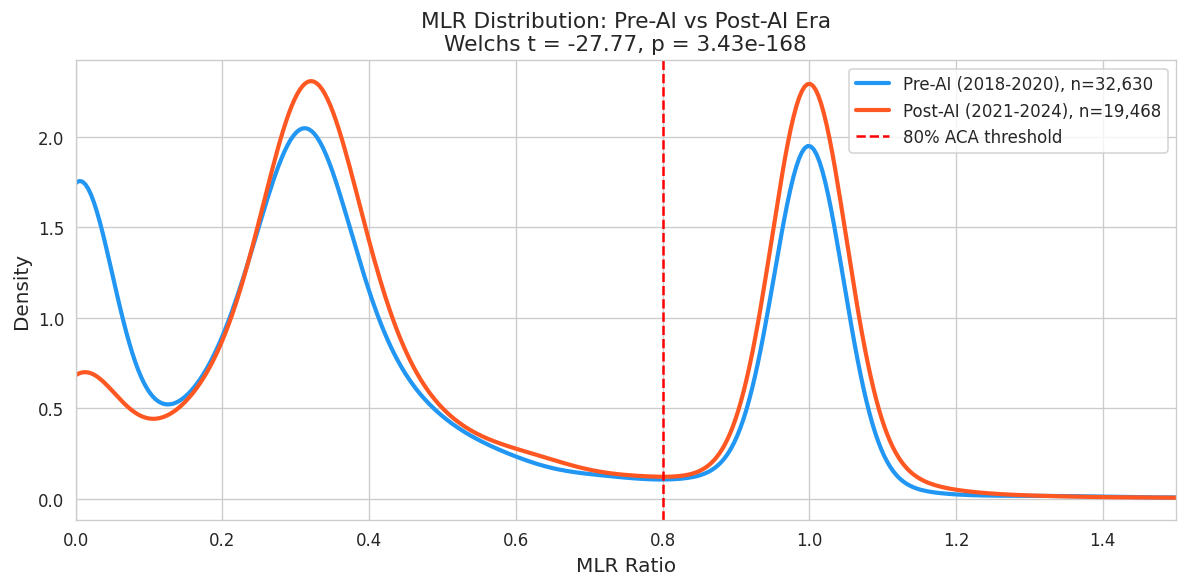

Saved: M04_preai_postai_density.png


In [ ]:
# 1.4 PRE-AI vs POST-AI MLR COMPARISON

valid = mlr_part3[mlr_part3['MLR_RATIO'].between(0, 2)].copy()
valid['_year_num'] = valid['_year'].astype(str).str.extract(r'(\d{4})')[0].astype(float)
valid = valid.dropna(subset=['_year_num'])
print(f'Year values found: {sorted(valid["_year_num"].unique())}')

pre_ai  = valid[valid['_year_num'] <= 2020]['MLR_RATIO']
post_ai = valid[valid['_year_num'] >= 2021]['MLR_RATIO']

print(f'Pre-AI  (2018-2020): n={len(pre_ai):,}, mean={pre_ai.mean():.4f}, std={pre_ai.std():.4f}')
print(f'Post-AI (2021-2024): n={len(post_ai):,}, mean={post_ai.mean():.4f}, std={post_ai.std():.4f}')

t_stat, t_pval = stats.ttest_ind(pre_ai, post_ai, equal_var=False)
print(f'\nWelchs t-test: t = {t_stat:.4f}, p = {t_pval:.2e}')
print(f'{"Significant" if t_pval < 0.05 else "Not significant"} at alpha=0.05')

pre_below  = (pre_ai < 0.80).mean() * 100
post_below = (post_ai < 0.80).mean() * 100
print(f'\nPercent below 80% threshold:')
print(f'  Pre-AI:  {pre_below:.1f}%')
print(f'  Post-AI: {post_below:.1f}%')
print(f'  Change:  {post_below - pre_below:+.1f} percentage points')

fig, ax = plt.subplots(figsize=(10, 5))
pre_ai.plot(kind='kde', ax=ax, color='#2196F3', lw=2.5, label=f'Pre-AI (2018-2020), n={len(pre_ai):,}')
post_ai.plot(kind='kde', ax=ax, color='#FF5722', lw=2.5, label=f'Post-AI (2021-2024), n={len(post_ai):,}')
ax.axvline(0.80, color='red', linestyle='--', lw=1.5, label='80% ACA threshold')
ax.set_xlabel('MLR Ratio', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'MLR Distribution: Pre-AI vs Post-AI Era\n'
             f'Welchs t = {t_stat:.2f}, p = {t_pval:.2e}', fontsize=13)
ax.legend()
ax.set_xlim(0, 1.5)
save_plot('M04_preai_postai_density.png')

In [ ]:
# 2.1 BETA REGRESSION - MLR Ratio Prediction

mlr_model = mlr_part3[mlr_part3['MLR_RATIO'].between(0.001, 0.999)].copy()
mlr_model['_year_num'] = mlr_model['_year'].astype(str).str.extract(r'(\d{4})')[0].astype(float)
mlr_model = mlr_model.dropna(subset=['_year_num', 'MLR_RATIO'])
mlr_model['POST_AI'] = (mlr_model['_year_num'] >= 2021).astype(int)

print(f'MLR modeling records: {len(mlr_model):,}')
print(f'Year range: {mlr_model["_year_num"].min():.0f} - {mlr_model["_year_num"].max():.0f}')
print(f'Pre-AI records: {(mlr_model["POST_AI"]==0).sum():,}')
print(f'Post-AI records: {(mlr_model["POST_AI"]==1).sum():,}')

mlr_model['MLR_CLIPPED'] = mlr_model['MLR_RATIO'].clip(0.001, 0.999)

try:
    glm_model = smf.glm(
        'MLR_CLIPPED ~ POST_AI + _year_num',
        data=mlr_model,
        family=sm.families.Binomial(link=sm.families.links.Logit())
    ).fit()
    print('\nGLM (Logit link) - Quasi-Beta Regression Results:')
    print(glm_model.summary().tables[1])
    print(f'\nAIC: {glm_model.aic:.2f}')
    print(f'Post-AI coefficient: {glm_model.params["POST_AI"]:.4f}')
    print(f'Post-AI p-value: {glm_model.pvalues["POST_AI"]:.4e}')
except Exception as e:
    print(f'GLM fitting issue: {e}')
    print('Falling back to OLS...')

ols_model = smf.ols('MLR_RATIO ~ POST_AI + _year_num', data=mlr_model).fit()
print('\nOLS Regression Results (for comparison):')
print(ols_model.summary().tables[1])
print(f'R-squared: {ols_model.rsquared:.4f}')
print(f'Adj R-squared: {ols_model.rsquared_adj:.4f}')

MLR modeling records: 32,437
Year range: 2018 - 2022
Pre-AI records: 19,811
Post-AI records: 12,626

GLM (Logit link) - Quasi-Beta Regression Results:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     58.9642     32.842      1.795      0.073      -5.405     123.333
POST_AI        0.1691      0.048      3.533      0.000       0.075       0.263
_year_num     -0.0295      0.016     -1.815      0.070      -0.061       0.002

AIC: 30312.20
Post-AI coefficient: 0.1691
Post-AI p-value: 4.1108e-04

OLS Regression Results (for comparison):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.9114      3.147      4.420      0.000       7.742      20.081
POST_AI        0.0387      0.005      8.427      0.000       0.030       0.048
_year_num     -0.0067    

Available years: [np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0)]
Temporal split: train years < 2022.0, test year = 2022.0
Train: 26,001, Test: 6,436

XGBoost Regression Results:
  RMSE: 0.1980
  R-squared: -0.0002


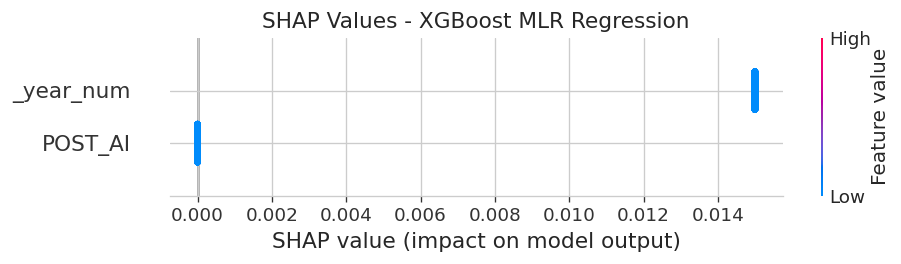

Saved: M05_xgb_mlr_shap.png


In [ ]:
# 2.1b GRADIENT BOOSTED REGRESSION - MLR Ratio

mlr_feat = mlr_model[['_year_num', 'POST_AI', 'MLR_RATIO']].dropna().copy()
print(f'Available years: {sorted(mlr_feat["_year_num"].unique())}')

X_mlr = mlr_feat[['_year_num', 'POST_AI']]
y_mlr = mlr_feat['MLR_RATIO']

max_year = mlr_feat['_year_num'].max()
train_mask = mlr_feat['_year_num'] < max_year

if train_mask.sum() == 0 or (~train_mask).sum() == 0:
    print('Temporal split not possible, using 80/20 random split')
    X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(
        X_mlr, y_mlr, test_size=0.2, random_state=42)
else:
    X_train_mlr, X_test_mlr = X_mlr[train_mask], X_mlr[~train_mask]
    y_train_mlr, y_test_mlr = y_mlr[train_mask], y_mlr[~train_mask]
    print(f'Temporal split: train years < {max_year}, test year = {max_year}')

print(f'Train: {len(X_train_mlr):,}, Test: {len(X_test_mlr):,}')

xgb_reg = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    min_child_weight=5, subsample=0.8, random_state=42
)
xgb_reg.fit(X_train_mlr, y_train_mlr)

y_pred_mlr = xgb_reg.predict(X_test_mlr)
rmse = np.sqrt(mean_squared_error(y_test_mlr, y_pred_mlr))
r2 = r2_score(y_test_mlr, y_pred_mlr)
print(f'\nXGBoost Regression Results:')
print(f'  RMSE: {rmse:.4f}')
print(f'  R-squared: {r2:.4f}')

if len(X_test_mlr) > 0:
    explainer = shap.TreeExplainer(xgb_reg)
    shap_values = explainer.shap_values(X_test_mlr)
    fig, ax = plt.subplots(figsize=(8, 4))
    shap.summary_plot(shap_values, X_test_mlr, show=False)
    plt.title('SHAP Values - XGBoost MLR Regression', fontsize=13)
    save_plot('M05_xgb_mlr_shap.png')

In [ ]:
# 2.2a MIXED-EFFECTS MODEL - SVI to Uninsured Rate

me_df = svi[['FIPS','STATE','RPL_THEMES','EP_UNINSUR']].copy()
me_df['RPL_THEMES'] = pd.to_numeric(me_df['RPL_THEMES'], errors='coerce')
me_df['EP_UNINSUR'] = pd.to_numeric(me_df['EP_UNINSUR'], errors='coerce')
me_df = me_df.dropna()
me_df = me_df[me_df['RPL_THEMES'].between(0, 1)]

print(f'Counties for mixed model: {len(me_df):,}')
print(f'States: {me_df["STATE"].nunique()}')

try:
    me_model = smf.mixedlm(
        'EP_UNINSUR ~ RPL_THEMES',
        data=me_df,
        groups=me_df['STATE'],
        re_formula='~RPL_THEMES'
    )
    me_result = me_model.fit(reml=True)
    print('\nMixed-Effects Model Results:')
    print(me_result.summary())

    beta_svi = me_result.fe_params['RPL_THEMES']
    p_svi    = me_result.pvalues['RPL_THEMES']
    print(f'\nFixed effect of SVI: beta = {beta_svi:.4f}, p = {p_svi:.4e}')
    print(f'Interpretation: 1-unit increase in SVI -> {beta_svi:.2f} pp increase in uninsured rate')
    print(f'\nRandom effects variance:')
    print(f'  Group (state intercept) var: {me_result.cov_re.iloc[0,0]:.4f}')

except Exception as e:
    print(f'Mixed model error: {e}')
    print('Trying simpler random intercept model...')
    me_model = smf.mixedlm(
        'EP_UNINSUR ~ RPL_THEMES',
        data=me_df,
        groups=me_df['STATE']
    )
    me_result = me_model.fit(reml=True)
    print(me_result.summary())

Counties for mixed model: 3,144
States: 51

Mixed-Effects Model Results:
              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    EP_UNINSUR
No. Observations:    3144       Method:                REML      
No. Groups:          51         Scale:                 9.0405    
Min. group size:     1          Log-Likelihood:        -8046.8761
Max. group size:     254        Converged:             Yes       
Mean group size:     61.6                                        
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               5.327    0.330 16.155 0.000  4.680  5.973
RPL_THEMES              6.718    0.699  9.609 0.000  5.348  8.088
Group Var               4.005    0.348                           
Group x RPL_THEMES Cov  0.038    0.496                           
RPL_THEMES Var   

Features: 13
Train: 2,515, Test: 629

Random Forest Regression Results:
  RMSE: 3.6124
  R-squared: 0.4694


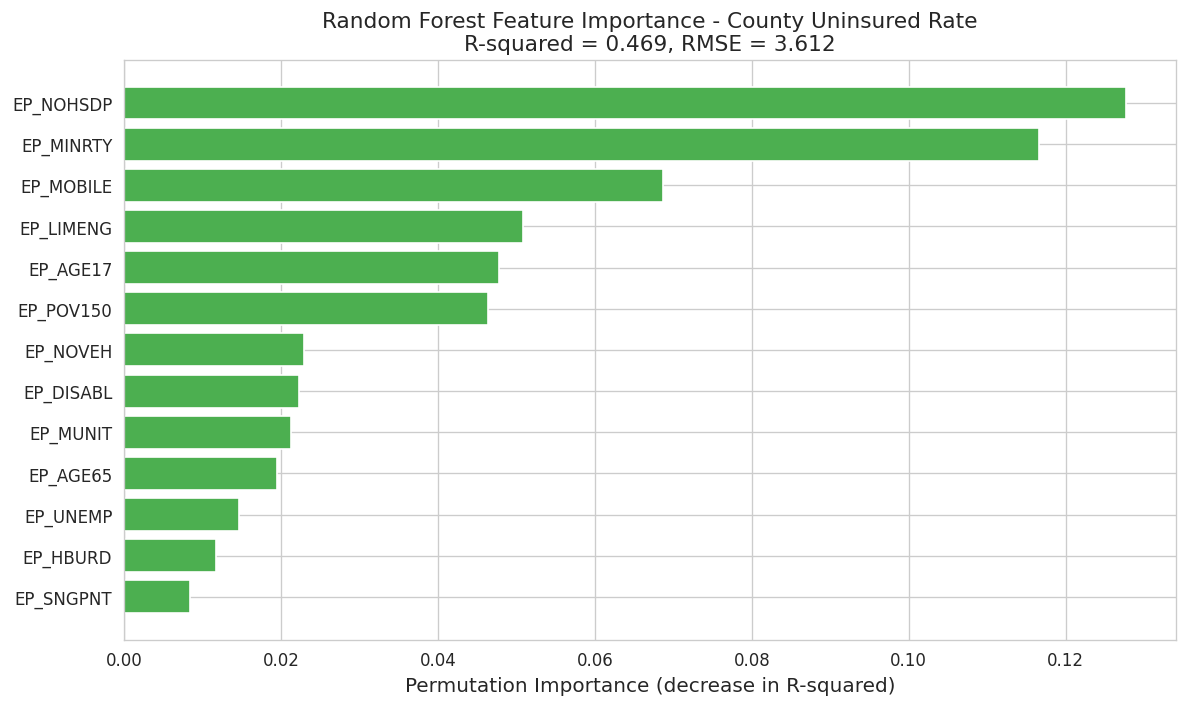

Saved: M06_rf_county_importance.png


In [ ]:
# 2.2b RANDOM FOREST REGRESSION - County Uninsured Rate

rf_vars = [c for c in svi_vars if c in svi.columns and c != 'EP_UNINSUR']
rf_df = svi[rf_vars + ['EP_UNINSUR']].apply(pd.to_numeric, errors='coerce').dropna()

X_county = rf_df[rf_vars]
y_county = rf_df['EP_UNINSUR']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_county, y_county, test_size=0.2, random_state=42
)

print(f'Features: {len(rf_vars)}')
print(f'Train: {len(X_tr):,}, Test: {len(X_te):,}')

rf_reg = RandomForestRegressor(
    n_estimators=500, max_depth=15, min_samples_leaf=5,
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf_reg.fit(X_tr, y_tr)

y_pred_county = rf_reg.predict(X_te)
rmse_c = np.sqrt(mean_squared_error(y_te, y_pred_county))
r2_c   = r2_score(y_te, y_pred_county)
print(f'\nRandom Forest Regression Results:')
print(f'  RMSE: {rmse_c:.4f}')
print(f'  R-squared: {r2_c:.4f}')

perm_imp = permutation_importance(rf_reg, X_te, y_te,
                                   n_repeats=10, random_state=42)
imp_df = pd.DataFrame({
    'Feature': rf_vars,
    'Importance': perm_imp.importances_mean
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['Feature'], imp_df['Importance'],
        color='#4CAF50', edgecolor='white')
ax.set_xlabel('Permutation Importance (decrease in R-squared)', fontsize=12)
ax.set_title(f'Random Forest Feature Importance - County Uninsured Rate\n'
             f'R-squared = {r2_c:.3f}, RMSE = {rmse_c:.3f}', fontsize=13)
save_plot('M06_rf_county_importance.png')

Counties for clustering: 3,144
Features: 14
  k=2: inertia=35403, silhouette=0.2385
  k=3: inertia=31441, silhouette=0.1903
  k=4: inertia=28628, silhouette=0.1751
  k=5: inertia=26821, silhouette=0.1366
  k=6: inertia=25216, silhouette=0.1383
  k=7: inertia=23713, silhouette=0.1421
  k=8: inertia=22656, silhouette=0.1332
  k=9: inertia=21889, silhouette=0.1180
  k=10: inertia=21256, silhouette=0.1073

Best k by silhouette: 2


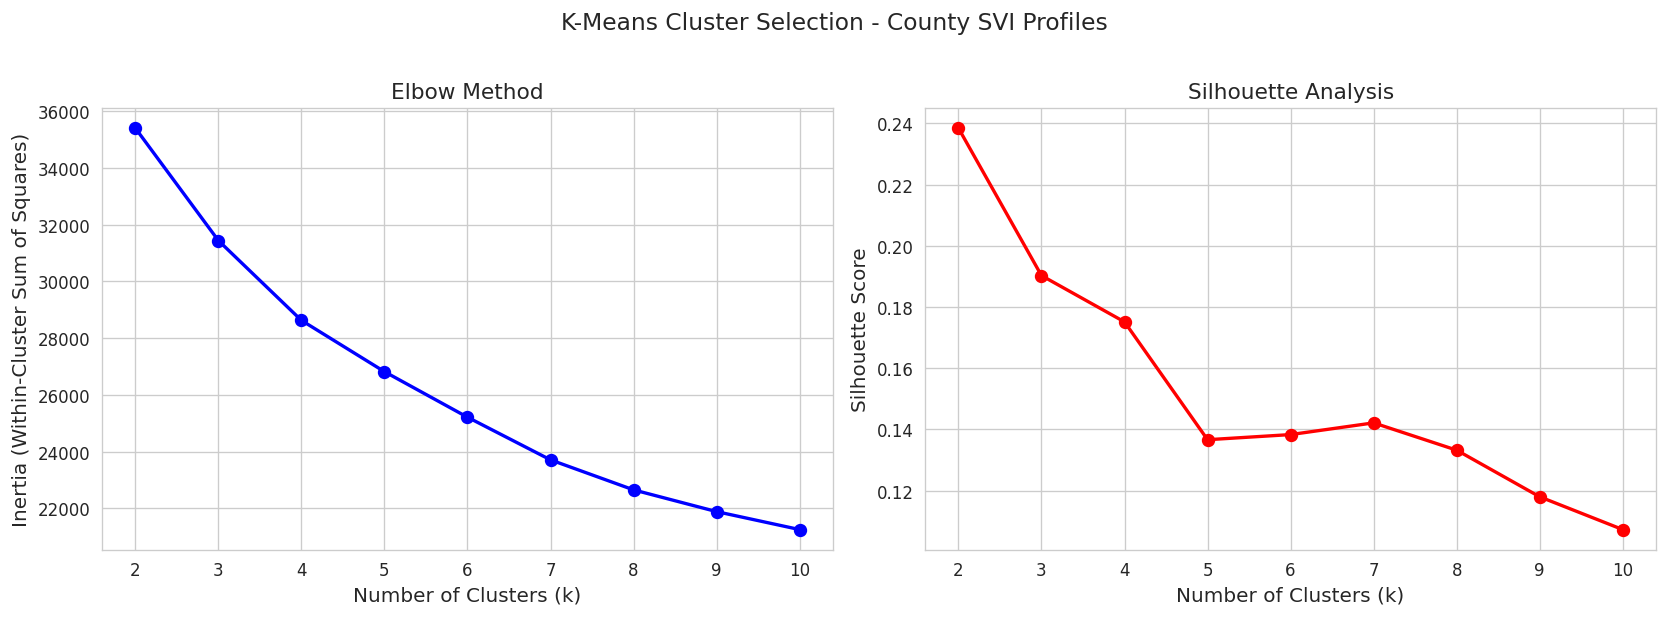

Saved: M13_kmeans_elbow_silhouette.png

Cluster sizes:
Cluster
0    1111
1    2033

Cluster profiles:
         count  avg_uninsured  std_uninsured  avg_EP_POV150  avg_EP_UNEMP  avg_EP_HBURD  avg_EP_NOHSDP  avg_EP_UNINSUR  avg_EP_AGE65
Cluster                                                                                                                             
0         1111         13.074          5.674         31.514         6.445        23.492         17.075          13.074        18.171
1         2033          7.567          3.410         19.823         4.135        20.961          8.680           7.567        20.541


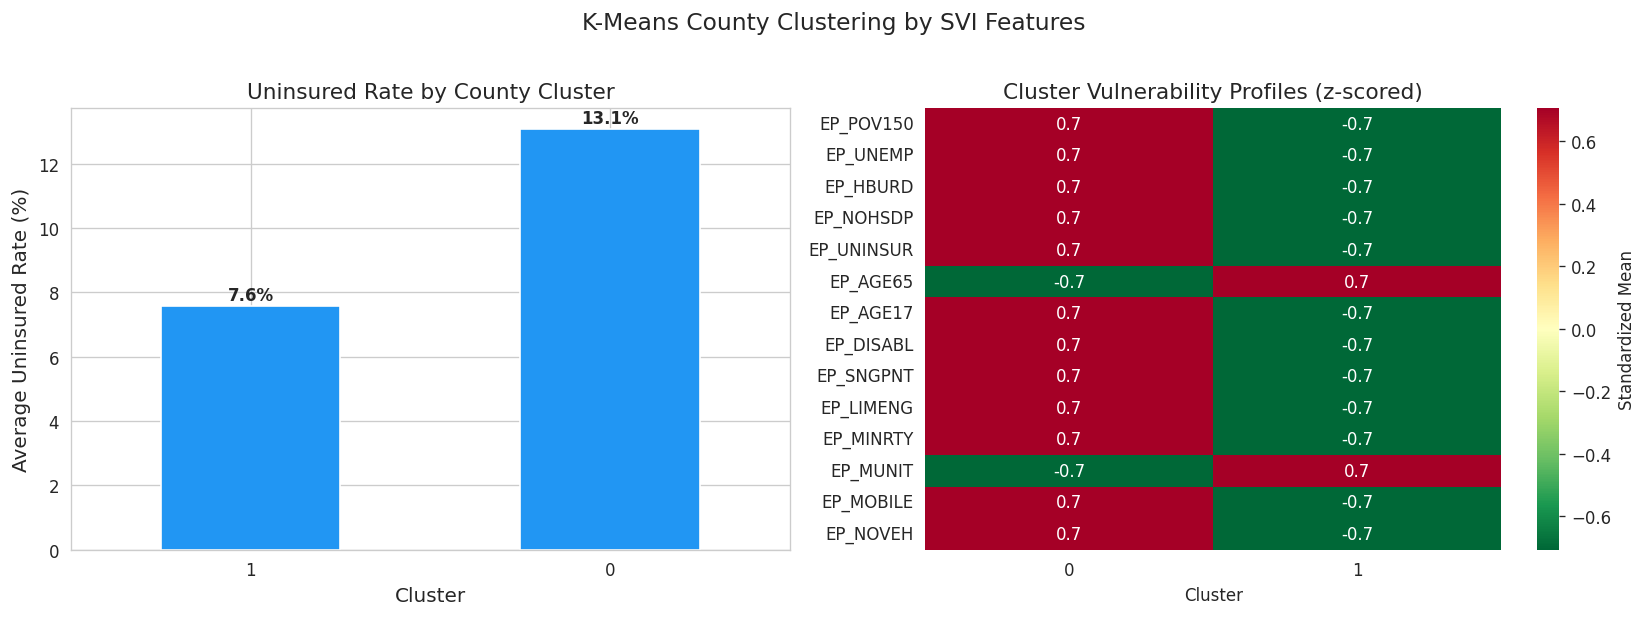

Saved: M14_kmeans_cluster_profiles.png


In [ ]:
# 2.2c K-MEANS CLUSTERING - County Vulnerability Profiles

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

svi_vars = ['EP_POV150','EP_UNEMP','EP_HBURD','EP_NOHSDP',
            'EP_UNINSUR','EP_AGE65','EP_AGE17','EP_DISABL',
            'EP_SNGPNT','EP_LIMENG','EP_MINRTY','EP_MUNIT',
            'EP_MOBILE','EP_NOVEH']

cluster_vars = [c for c in svi_vars if c in svi.columns]

cluster_df = svi[['FIPS']].copy()
for c in cluster_vars:
    cluster_df[c] = pd.to_numeric(svi[c], errors='coerce')
cluster_df['EP_UNINSUR'] = pd.to_numeric(svi['EP_UNINSUR'], errors='coerce')
cluster_df = cluster_df.dropna()

scaler_km = StandardScaler()
X_cluster = scaler_km.fit_transform(cluster_df[cluster_vars])

print(f'Counties for clustering: {len(cluster_df):,}')
print(f'Features: {len(cluster_vars)}')

inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))
    print(f'  k={k}: inertia={km.inertia_:.0f}, silhouette={sil_scores[-1]:.4f}')

best_k = list(K_range)[np.argmax(sil_scores)]
print(f'\nBest k by silhouette: {best_k}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', lw=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13)

axes[1].plot(list(K_range), sil_scores, 'ro-', lw=2, markersize=7)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=13)

plt.suptitle('K-Means Cluster Selection - County SVI Profiles', fontsize=14, y=1.02)
save_plot('M13_kmeans_elbow_silhouette.png')

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df['Cluster'] = km_final.fit_predict(X_cluster)

print(f'\nCluster sizes:')
print(cluster_df['Cluster'].value_counts().sort_index().to_string())

cluster_summary = cluster_df.groupby('Cluster').agg(
    count=('FIPS', 'count'),
    avg_uninsured=('EP_UNINSUR', 'mean'),
    std_uninsured=('EP_UNINSUR', 'std'),
).round(3)

for var in cluster_vars[:6]:
    cluster_summary[f'avg_{var}'] = cluster_df.groupby('Cluster')[var].mean().round(3)

print(f'\nCluster profiles:')
print(cluster_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cluster_means = cluster_df.groupby('Cluster')['EP_UNINSUR'].mean().sort_values()
cluster_means.plot(kind='bar', ax=ax, color='#2196F3', edgecolor='white')
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Average Uninsured Rate (%)', fontsize=12)
ax.set_title('Uninsured Rate by County Cluster', fontsize=13)
for i, v in enumerate(cluster_means.values):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.sca(ax)
plt.xticks(rotation=0)

ax = axes[1]
cluster_profiles = cluster_df.groupby('Cluster')[cluster_vars].mean()
cluster_profiles_z = (cluster_profiles - cluster_profiles.mean()) / cluster_profiles.std()
sns.heatmap(cluster_profiles_z.T, annot=True, fmt='.1f', cmap='RdYlGn_r',
            center=0, ax=ax, cbar_kws={'label': 'Standardized Mean'})
ax.set_title('Cluster Vulnerability Profiles (z-scored)', fontsize=13)
ax.set_xlabel('Cluster')

plt.suptitle('K-Means County Clustering by SVI Features', fontsize=14, y=1.02)
save_plot('M14_kmeans_cluster_profiles.png')

In [ ]:
# 2.3 PREPARE CLASSIFICATION DATA FOR RQ3

cat_features = ['RACE_LABEL', 'SEX_LABEL', 'AGE_GROUP']
num_features = ['CONDITION_COUNT', 'AGE']
cond_features = [c for c in existing]

model_df = merged[cat_features + num_features + cond_features + ['DENIED']].copy()
model_df = model_df.dropna()

model_df = pd.get_dummies(model_df, columns=cat_features, drop_first=True)

for col in cond_features:
    model_df[col] = (model_df[col] == 1).astype(int)

X = model_df.drop('DENIED', axis=1)
y = model_df['DENIED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
num_cols = ['CONDITION_COUNT', 'AGE']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print(f'Features: {X.shape[1]}')
print(f'Train: {len(X_train):,} (denial rate: {y_train.mean()*100:.2f}%)')
print(f'Test: {len(X_test):,} (denial rate: {y_test.mean()*100:.2f}%)')
print(f'Feature names: {list(X.columns)}')

In [ ]:
# 2.3.1 LOGISTIC REGRESSION

lr = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=42
)
lr.fit(X_train, y_train)

y_pred_lr  = lr.predict(X_test)
y_prob_lr  = lr.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred_lr, digits=4))

roc_lr  = roc_auc_score(y_test, y_prob_lr)
pr_lr   = average_precision_score(y_test, y_prob_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
mcc_lr  = matthews_corrcoef(y_test, y_pred_lr)
print(f'ROC-AUC: {roc_lr:.4f}')
print(f'PR-AUC:  {pr_lr:.4f}')
print(f'F1:      {f1_lr:.4f}')
print(f'MCC:     {mcc_lr:.4f}')

print('\nTop Odds Ratios:')
or_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_[0],
    'Odds Ratio': np.exp(lr.coef_[0])
}).sort_values('Odds Ratio', ascending=False)
print(or_df.head(10).to_string(index=False))

In [ ]:
# 2.3.2 BALANCED RANDOM FOREST

brf = BalancedRandomForestClassifier(
    n_estimators=500, max_depth=15, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
brf.fit(X_train, y_train)

y_pred_brf = brf.predict(X_test)
y_prob_brf = brf.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred_brf, digits=4))

roc_brf = roc_auc_score(y_test, y_prob_brf)
pr_brf  = average_precision_score(y_test, y_prob_brf)
f1_brf  = f1_score(y_test, y_pred_brf)
mcc_brf = matthews_corrcoef(y_test, y_pred_brf)
print(f'ROC-AUC: {roc_brf:.4f}')
print(f'PR-AUC:  {pr_brf:.4f}')
print(f'F1:      {f1_brf:.4f}')
print(f'MCC:     {mcc_brf:.4f}')

fi_brf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': brf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi_brf['Feature'].tail(15), fi_brf['Importance'].tail(15),
        color='#4CAF50', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title(f'Balanced Random Forest - Top 15 Feature Importances\n'
             f'Predicting Claim Denial (ROC-AUC = {roc_brf:.3f})', fontsize=13)
save_plot('M07_brf_feature_importance.png')

In [ ]:
# 2.3.3 XGBOOST CLASSIFIER

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f'scale_pos_weight: {spw:.1f}')

xgb_clf = xgb.XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    scale_pos_weight=spw, subsample=0.8,
    min_child_weight=5, eval_metric='aucpr',
    random_state=42, use_label_encoder=False
)
xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb, digits=4))

roc_xgb = roc_auc_score(y_test, y_prob_xgb)
pr_xgb  = average_precision_score(y_test, y_prob_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb)
mcc_xgb = matthews_corrcoef(y_test, y_pred_xgb)
print(f'ROC-AUC: {roc_xgb:.4f}')
print(f'PR-AUC:  {pr_xgb:.4f}')
print(f'F1:      {f1_xgb:.4f}')
print(f'MCC:     {mcc_xgb:.4f}')

print('\nComputing SHAP values...')
explainer_xgb = shap.TreeExplainer(xgb_clf)
shap_vals_xgb = explainer_xgb.shap_values(X_test)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_vals_xgb, X_test, show=False, max_display=15)
plt.title('XGBoost SHAP Values - Claim Denial Prediction', fontsize=13)
save_plot('M08_xgb_denial_shap.png')

In [ ]:
# 2.3.4 NEURAL NETWORK (MLP)

sm_obj = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm_obj.fit_resample(X_train, y_train)
print(f'After SMOTE - Train: {len(X_train_sm):,}')
print(f'Class balance: {pd.Series(y_train_sm).value_counts().to_dict()}')

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=10,
    random_state=42
)
mlp.fit(X_train_sm, y_train_sm)

y_pred_mlp = mlp.predict(X_test)
y_prob_mlp = mlp.predict_proba(X_test)[:, 1]

print('\nClassification Report:')
print(classification_report(y_test, y_pred_mlp, digits=4))

roc_mlp = roc_auc_score(y_test, y_prob_mlp)
pr_mlp  = average_precision_score(y_test, y_prob_mlp)
f1_mlp  = f1_score(y_test, y_pred_mlp)
mcc_mlp = matthews_corrcoef(y_test, y_pred_mlp)
print(f'ROC-AUC: {roc_mlp:.4f}')
print(f'PR-AUC:  {pr_mlp:.4f}')
print(f'F1:      {f1_mlp:.4f}')
print(f'MCC:     {mcc_mlp:.4f}')

In [ ]:
# 2.4 SOFT VOTING ENSEMBLE

y_prob_ensemble = (y_prob_lr + y_prob_brf + y_prob_xgb + y_prob_mlp) / 4

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_test, (y_prob_ensemble >= t).astype(int))
             for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f'Best threshold (max F1): {best_thresh:.2f}')

y_pred_ens = (y_prob_ensemble >= best_thresh).astype(int)

print('\nEnsemble Classification Report:')
print(classification_report(y_test, y_pred_ens, digits=4))

roc_ens = roc_auc_score(y_test, y_prob_ensemble)
pr_ens  = average_precision_score(y_test, y_prob_ensemble)
f1_ens  = f1_score(y_test, y_pred_ens)
mcc_ens = matthews_corrcoef(y_test, y_pred_ens)
print(f'ROC-AUC: {roc_ens:.4f}')
print(f'PR-AUC:  {pr_ens:.4f}')
print(f'F1:      {f1_ens:.4f}')
print(f'MCC:     {mcc_ens:.4f}')

In [ ]:
# COMPARISON PLOTS - ROC Curves and Model Summary

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for name, y_prob, color in [
    ('Logistic Reg', y_prob_lr, '#2196F3'),
    ('Balanced RF', y_prob_brf, '#4CAF50'),
    ('XGBoost', y_prob_xgb, '#FF9800'),
    ('Neural Net', y_prob_mlp, '#9C27B0'),
    ('Ensemble', y_prob_ensemble, '#E91E63'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_val:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - All Models', fontsize=13)
ax.legend(fontsize=9)

ax = axes[1]
for name, y_prob, color in [
    ('Logistic Reg', y_prob_lr, '#2196F3'),
    ('Balanced RF', y_prob_brf, '#4CAF50'),
    ('XGBoost', y_prob_xgb, '#FF9800'),
    ('Neural Net', y_prob_mlp, '#9C27B0'),
    ('Ensemble', y_prob_ensemble, '#E91E63'),
]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')
ax.axhline(y_test.mean(), color='gray', linestyle=':', lw=1.5, label='Baseline')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - All Models', fontsize=13)
ax.legend(fontsize=9)

save_plot('M09_roc_pr_comparison.png')

summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Balanced Random Forest',
              'XGBoost', 'Neural Network (MLP)', 'Soft Voting Ensemble'],
    'ROC-AUC': [roc_lr, roc_brf, roc_xgb, roc_mlp, roc_ens],
    'PR-AUC':  [pr_lr, pr_brf, pr_xgb, pr_mlp, pr_ens],
    'F1':      [f1_lr, f1_brf, f1_xgb, f1_mlp, f1_ens],
    'MCC':     [mcc_lr, mcc_brf, mcc_xgb, mcc_mlp, mcc_ens],
}).round(4)

print('\nMODEL COMPARISON SUMMARY - Claim Denial Prediction')
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(summary))
w = 0.2
ax.bar(x - 1.5*w, summary['ROC-AUC'], w, label='ROC-AUC', color='#2196F3')
ax.bar(x - 0.5*w, summary['PR-AUC'], w, label='PR-AUC', color='#4CAF50')
ax.bar(x + 0.5*w, summary['F1'], w, label='F1', color='#FF9800')
ax.bar(x + 1.5*w, summary['MCC'], w, label='MCC', color='#9C27B0')
ax.set_xticks(x)
ax.set_xticklabels(summary['Model'], rotation=25, ha='right')
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison - Claim Denial Prediction (RQ3)', fontsize=13)
ax.legend()
ax.set_ylim(0, 1)
save_plot('M10_model_comparison_bars.png')

In [ ]:
# 2.5 FAIRNESS AUDIT

from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    MetricFrame
)

test_idx = X_test.index
race_test = merged.loc[test_idx, 'RACE_LABEL'].values

y_pred_best = y_pred_xgb

mf = MetricFrame(
    metrics={
        'Accuracy': lambda y_t, y_p: (y_t == y_p).mean(),
        'Denial Prediction Rate': lambda y_t, y_p: y_p.mean(),
        'True Positive Rate': lambda y_t, y_p: y_p[y_t == 1].mean() if (y_t == 1).sum() > 0 else 0,
        'False Positive Rate': lambda y_t, y_p: y_p[y_t == 0].mean() if (y_t == 0).sum() > 0 else 0,
    },
    y_true=y_test.values,
    y_pred=y_pred_best,
    sensitive_features=race_test
)

print('Fairness Metrics by Race (XGBoost):')
print(mf.by_group.round(4).to_string())

dp_diff = demographic_parity_difference(
    y_test, y_pred_best, sensitive_features=race_test
)
eo_diff = equalized_odds_difference(
    y_test, y_pred_best, sensitive_features=race_test
)
print(f'\nDemographic Parity Difference: {dp_diff:.4f}')
print(f'Equalized Odds Difference: {eo_diff:.4f}')
print('(0 = perfect fairness, higher = more disparity)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
by_group = mf.by_group
if 'Denial Prediction Rate' in by_group.columns:
    by_group['Denial Prediction Rate'].plot(
        kind='bar', ax=ax, color=['#2196F3','#E91E63','#4CAF50','#FF9800'],
        edgecolor='white'
    )
    ax.set_ylabel('Predicted Denial Rate', fontsize=12)
    ax.set_title('Denial Prediction Rate by Race', fontsize=13)
    plt.sca(ax)
    plt.xticks(rotation=30)

ax = axes[1]
if 'True Positive Rate' in by_group.columns:
    by_group['True Positive Rate'].plot(
        kind='bar', ax=ax, color=['#2196F3','#E91E63','#4CAF50','#FF9800'],
        edgecolor='white'
    )
    ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
    ax.set_title('Equalized Odds: TPR by Race', fontsize=13)
    plt.sca(ax)
    plt.xticks(rotation=30)

plt.suptitle(f'Fairness Audit - XGBoost Claim Denial Model\n'
             f'Demographic Parity Diff = {dp_diff:.3f}, '
             f'Equalized Odds Diff = {eo_diff:.3f}', fontsize=14, y=1.05)
save_plot('M11_fairness_audit.png')

In [ ]:
# FEATURE CORRELATION WITH DENIAL

fi_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_clf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

top_feats = fi_xgb['Feature'].tolist()

corr_with_denial = model_df[top_feats + ['DENIED']].corr()['DENIED'].drop('DENIED')
corr_with_denial = corr_with_denial.reindex(top_feats)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#4CAF50' if v >= 0 else '#FF5722' for v in corr_with_denial.values]
bars = ax.barh(corr_with_denial.index[::-1], corr_with_denial.values[::-1],
               color=colors[::-1], edgecolor='white')
for bar, val in zip(bars, corr_with_denial.values[::-1]):
    ax.text(bar.get_width() + 0.005 * np.sign(bar.get_width()),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlation with Claim Denial', fontsize=12)
ax.set_title('XGBoost Top 15 Features - Correlation with Denial\n'
             'Green = positive (increases denial), Red = negative (decreases denial)',
             fontsize=13)
save_plot('M12_feature_correlation_denial.png')

In [ ]:
# FINAL SUMMARY

saved = [f for f in os.listdir(PLOT_DIR) if f.endswith('.png')]
print(f'Methodology plots saved: {len(saved)}')
for f in sorted(saved):
    print(f'  {f}')

print(f'\nLocation: {PLOT_DIR}')
print('\nModels trained:')
print('  Beta Regression / GLM (RQ1)')
print('  XGBoost Regression (RQ1)')
print('  Mixed-Effects Model (RQ2)')
print('  Random Forest Regression (RQ2)
  K-Means Clustering (RQ2)')
print('  Logistic Regression (RQ3)')
print('  Balanced Random Forest (RQ3)')
print('  XGBoost Classifier (RQ3)')
print('  Neural Network / MLP (RQ3)')
print('  Soft Voting Ensemble (RQ3)')
print('  Fairness Audit (RQ3)')